In [ ]:
import numpy as np
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
from torch import Tensor
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch.optim as optim
from tqdm import tqdm
from scipy.special import gamma as gamma_function
from scipy import stats

In [ ]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

In [ ]:
def normal_distribution(x, mu, sigma):
    return (1/(sigma*2*np.pi)*np.exp(-(1/2)*((x-mu)/sigma)**2))


### Machine learning code

In [ ]:
def fwd_pass(net, X:Tensor, y:Tensor, device, optimizer, train=False, gaussian_NLL=False):
    """
    This function controls the machine learning steps, depending on if we are in training mode or not.
    """
    if train:
        net.train()
        net.zero_grad()
    outputs = net(X.to(device))
    if gaussian_NLL:
        preds, variances = outputs.tensor_split(2, -1)
        variances = nn.functional.softplus(variances)
        loss = F.gaussian_nll_loss(preds, y.to(device), var=variances).to(device)
    else:
        loss = F.mse_loss(outputs, y.to(device)).to(device)
    if train:
        loss.backward()
        optimizer.step()
    return loss

def train(net, traindata, valdata, batchsize:int, epochs:int, device, optimizer, patience=5, gaussian_NLL=False, verbose=True):
    """
    Trains the model for the number of epochs specified, using the batch size specified.
    Returns a dataframe with the stats from the training.
    """
    dataset = DataLoader(traindata, batchsize, shuffle=True)
    df_labels = ["Loss", "Validation loss", "Epoch", "Iteration"]
    df_data = [[0], [0], [0], [0]]
    df = pd.DataFrame(dict(zip(df_labels, df_data)))
    i = 0
    epoch = 0
    min_loss = 999
    loss_count = 0

    while (loss_count < patience) and (epoch < epochs):
        for data in dataset:
            X, y = data
            #print(X[0], y[0])
            loss = fwd_pass(net, X, y, device, optimizer, train=True, gaussian_NLL=gaussian_NLL)
            #acc, loss = test(net, testdata, size=size)
            val_loss = test(net, valdata, device, optimizer, size=len(valdata), gaussian_NLL=gaussian_NLL)
            df_data = [float(loss), float(val_loss), epoch, i]
            new_df = pd.DataFrame(dict(zip(df_labels, df_data)), index=[0])
            df = pd.concat([df, new_df], ignore_index=True)
            i = i+1
        if val_loss <= min_loss:
            min_loss = val_loss
        else:
            loss_count = loss_count + 1
        epoch = epoch + 1
    if verbose:
        print(f"Stopping training at epoch {epoch}")
    return df

def test(net, data, device, optimizer, size:int = 32, gaussian_NLL=False):
    """
    Calculates the accuracy and the loss of the model for a random batch.
    """
    net.eval()
    dataset = DataLoader(data, size, shuffle=True) #shuffle data and choose batch size
    X, y = next(iter(dataset)) #get a random batch
    val_loss = fwd_pass(net, X, y, device, optimizer, train=False, gaussian_NLL=gaussian_NLL)
    return val_loss
    
def predict(net, testdata, size:int, device, gaussianNLL=False):
    """
    Calculates the accuracy and the loss of the model in testing mode.
    If return_loss is True, it will return the loss for each datapoint.
    It can also return the softmax values of the raw output from the model.
    Does not shuffle the data.
    """
    dataset = DataLoader(testdata, size, shuffle=False) #shuffle data and choose batch size
    input = torch.zeros((len(dataset), size))
    prediction = torch.zeros((len(dataset), size))
    if gaussianNLL:
        variances = torch.zeros((len(dataset), size))
    truth = torch.zeros((len(dataset), size))
    i = 0
    net.eval()
    with torch.no_grad():
        for data in dataset:
            X, y = data
            input[i] = X
            outputs = net(X.to(device))
            if gaussianNLL:
                prediction[i], variances[i] = outputs.tensor_split(2, -1)
                variances[i] = nn.functional.softplus(variances[i])
            else:
                prediction[i] = outputs
            truth[i] = y
            i = i+1
    if gaussianNLL:
        return torch.flatten(input), torch.flatten(truth), torch.flatten(prediction), torch.flatten(variances)
    else:
        return torch.flatten(input), torch.flatten(truth), torch.flatten(prediction)
    
class SequentialNet(nn.Module):

    def __init__(self, activation:str, in_channels:int, out_channels:int, L: int = 1024, 
                 n_hidden:int = 1, p:float = 0):
        assert activation in ["relu", "tanh", "sigmoid", "leakyrelu"], "should be a a valid activation function"
        super().__init__()
        
        layers = []
        for i in range(n_hidden):
            layers.append(nn.Linear(L, L))
            if p > 0:
                layers.append(nn.Dropout(p))
            if activation == "relu":
                layers.append(nn.ReLU())
            elif activation == "tanh":
                layers.append(nn.Tanh())
            elif activation == "sigmoid":
                layers.append(nn.Sigmoid())
            elif activation == "leakyrelu":
                layers.append(nn.LeakyReLU())
        self.hidden_layers = nn.Sequential(*layers)
        self.first_layer = nn.Linear(in_channels, L)
        self.last_layer = nn.Linear(L, out_channels)
        self.dropout = nn.Dropout(p) 

    def forward(self, x):
        x = self.first_layer(x)
        #x = self.dropout(x)
        x = self.hidden_layers(x)
        x = self.last_layer(x)
        return x
    
def train_nn(df, test_df, n_nodes=500, n_hidden=4, lr=0.001, batchsize=100, epochs=100, patience=5, gaussianNLL=False, verbose=True):
    ndata = len(df)
    x_mean = df["x"].mean()
    x_std = df["x"].std()
    y_mean = df["y"].mean()
    y_std = df["y"].std()
    df = df.sample(frac=1) #Shuffle data
    #Normalize
    x = torch.tensor((df["x"]-x_mean)/x_std).reshape(ndata, 1).to(torch.float32)
    y = torch.tensor((df["y"]-y_mean)/y_std).reshape(ndata, 1).to(torch.float32)
    dset = torch.utils.data.TensorDataset(x, y)

    train_dataset, val_dataset = torch.utils.data.random_split(dset, [int(ndata-ndata/10), int(ndata/10)])
    if verbose:
        print(f"Creating training and validation sets of size {len(train_dataset), len(val_dataset)}")

    if batchsize > len(train_dataset):
        batchsize = len(train_dataset)
        if verbose:
            print(f"Setting batchsize to {batchsize}.")
    
    if gaussianNLL:
        model = SequentialNet(L=n_nodes, n_hidden=n_hidden, activation="relu", in_channels=1, out_channels=2).to(device)
    else:
        model = SequentialNet(L=n_nodes, n_hidden=n_hidden, activation="relu", in_channels=1, out_channels=1).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=0)
    training_results = train(model, train_dataset, 
                            val_dataset, batchsize=batchsize, epochs = epochs, 
                            device = device, optimizer = optimizer, patience=patience, gaussian_NLL=gaussianNLL, verbose=verbose)
    ntest =len(test_df)
    x = torch.tensor((test_df["x"]-x_mean)/x_std).reshape(ntest, 1).to(torch.float32)
    y = torch.tensor((test_df["y"]-y_mean)/y_std).reshape(ntest, 1).to(torch.float32)
    test_dataset = torch.utils.data.TensorDataset(x, y)
    if gaussianNLL:
        input, target, preds, variances = predict(model, test_dataset, 1, device, gaussianNLL=True)
        #test_df = pd.DataFrame({"x":input, "y": target})
        test_df["y_est"] = preds*y_std + y_mean
        test_df["vars_est"] = variances*y_std
        # 95% prediction interval
        alpha = 0.05
        n = len(train_dataset)
        t = stats.t(df=n-2).ppf(1-(alpha)/2)
        test_df["95CI_y_lower"] = test_df["y_est"] - t*np.sqrt(test_df["vars_est"])*(1+1/n)
        test_df["95CI_y_upper"] = test_df["y_est"] + t*np.sqrt(test_df["vars_est"])*(1+1/n)

        # 70% prediction interval
        alpha = 0.3
        n = len(train_dataset)
        t = stats.t(df=n-2).ppf(1-(alpha)/2)
        test_df["70CI_y_lower"] = test_df["y_est"] - t*np.sqrt(test_df["vars_est"])*(1+1/n)
        test_df["70CI_y_upper"] = test_df["y_est"] + t*np.sqrt(test_df["vars_est"])*(1+1/n)
    else:
        input, target, preds = predict(model, test_dataset, 1, device)
        #test_df = pd.DataFrame({"x":input, "y": target})
        test_df["y_est"] = preds*y_std + y_mean
    test_df = test_df.sort_values(by="x")
    return test_df, training_results

### Plotting code


In [ ]:
def plot_normal(xmin, xmax, mu=0, sigma=1):
    fig, ax = plt.subplots(figsize=(9,7))

    x = np.linspace(xmin, xmax, 1000)
    y = normal_distribution(x, mu, sigma)


    ax.plot(x,y, label=rf"$\mathcal{{N}}(x|\mu={mu}, \sigma={sigma})$", linewidth=3, color="#623969")
    mask = np.abs(x-mu) < 2*sigma
    ax.fill_between(x[mask], np.zeros(np.sum(mask)), y[mask], alpha=1, color="#7fc97f", label=r"$\int_{-\mu+2\sigma}^{\mu-2\sigma}\text{ }p(x) dx=95\%$")

    mask = np.abs(x-mu) < sigma
    ax.fill_between(x[mask], np.zeros(np.sum(mask)), y[mask], alpha=1, color="#6f9dd9", label=r"$\int_{-\mu+\sigma}^{\mu-\sigma}\text{ }p(x) dx=68\%$")

    ax.set_xlabel("x", fontsize=18)
    ax.set_ylabel("p(x)", fontsize=18)
    ax.legend(fontsize=14)
    ax.set_ylim(0, None)
    ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=5, length=6, width=1, labelsize=14)
    ax.set_xlim(xmin, xmax)
    #ax.grid(True)

def plot_normal_experiment(n, f, ci_level):
    fig, ax = plt.subplots(figsize=(9,7))

    ax.plot(n,[ci_level]*len(n), label=rf"(1-$\alpha$) = {ci_level}", linewidth=2, linestyle = "--")
    ax.plot(n,f, label=rf"Fraction trials in CI", linewidth=2)
    
    ax.set_xlabel("Number of trials", fontsize=18)
    ax.set_ylabel("Frequency", fontsize=18)
    ax.legend(fontsize=14)
    ax.set_ylim(0, None)
    ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=5, length=6, width=1, labelsize=14)
    ax.set_xlim(np.min(n), np.max(n))
    #ax.grid(True)

def plot_experiment_LR(df):
    fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(12,6), layout="constrained")
    sn.histplot(df, x="A_est", bins=30, ax = axs[0][0], stat="probability")
    axs[0][0].plot([df["A_est"].mean()]*2, [0, 1], color="#f42023d6", linewidth=2, label=r"Average $\hat{A}$")
    axs[0][0].plot([df["a"].mean()]*2, [0, 1], color="black", linewidth=2, linestyle="--", label="a")
    axs[0][0].legend()
    axs[0][0].set_xlabel(r"$\hat{A}$")

    sn.histplot(df, x="B_est", bins=30, ax = axs[0][1], stat="probability")
    axs[0][1].plot([df["B_est"].mean()]*2, [0, 1], color="#f42023d6", linewidth=2, label=r"Average $\hat{B}$")
    axs[0][1].plot([df["b"].mean()]*2, [0, 1], color="black", linewidth=2, linestyle="--", label="b")
    axs[0][1].set_xlabel(r"$\hat{B}$", fontsize=14)

    sn.histplot(df, x="var_est", bins=30, ax = axs[0][2], stat="probability")
    axs[0][2].plot([df["var_est"].mean()]*2, [0, 1], color="#f42023d6", linewidth=2, label=r"Average $\hat{\sigma}^2$")
    axs[0][2].plot([df["var"].mean()]*2, [0, 1], color="black", linewidth=2, linestyle="--", label=r"$\sigma_Y^2$")
    axs[0][2].set_xlabel(r"$\hat{\sigma}_Y^2$", fontsize=14)

    sn.histplot(df, x="efficiency_95CI_mu", bins=30, ax = axs[1][0], stat="probability")
    axs[1][0].plot([df["efficiency_95CI_mu"].mean()]*2, [0, 1], color="#f42023d6", linewidth=2, label="Average fraction")
    axs[1][0].plot([0.95]*2, [0, 1], color="black", linewidth=2, linestyle="--", label="0.95")
    axs[1][0].set_xlabel(r"Fraction $\mu$ within 95% CI", fontsize=14)
    axs[1][0].legend()
    
    sn.histplot(df, x="efficiency_95CI_y", bins=30, ax = axs[1][1], stat="probability")
    axs[1][1].plot([df["efficiency_95CI_y"].mean()]*2, [0, 1], color="#f42023d6", linewidth=2, label="Average fraction")
    axs[1][1].plot([0.95]*2, [0, 1], color="black", linewidth=2, linestyle="--", label="0.95")
    axs[1][1].set_xlabel(r"Fraction y within 95% CI", fontsize=14)
    axs[1][1].set_xlim(0.8, 1)

    sn.histplot(df, x="efficiency_70CI_y", bins=30, ax = axs[1][2], stat="probability")
    axs[1][2].plot([df["efficiency_70CI_y"].mean()]*2, [0, 1], color="#f42023d6", linewidth=2, label="Average fraction")
    axs[1][2].plot([0.70]*2, [0, 1], color="black", linewidth=2, linestyle="--", label="0.70")
    axs[1][2].set_xlabel(r"Fraction y within 70% CI", fontsize=14)
    axs[1][2].set_xlim(0.5, 1)
    
    for ax in axs.flatten():
        ax.set_ylabel("Frequency", fontsize=14)
        ax.set_ylim(0, 0.2)
        ax.legend(fontsize=12)
        ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=2, length=4, width=1, labelsize=12)
    
    axs[1][0].set_ylim(0, 0.9)
    axs[1][1].set_ylim(0, 0.3)
    axs[1][2].set_ylim(0, 0.3)

def plot_experiment_NN(df):
    fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(9,4), layout="constrained")

    
    sn.histplot(df, x="efficiency_95CI_y", bins=30, ax = axs[0], stat="probability")
    axs[0].plot([df["efficiency_95CI_y"].mean()]*2, [0, 1], color="#f42023d6", linewidth=2, label="Average fraction")
    axs[0].plot([0.95]*2, [0, 1], color="black", linewidth=2, linestyle="--", label="0.95")
    axs[0].set_xlabel(r"Fraction y within 95% CI", fontsize=14)
    axs[0].set_xlim(0.8, 1)

    sn.histplot(df, x="efficiency_70CI_y", bins=30, ax = axs[1], stat="probability")
    axs[1].plot([df["efficiency_70CI_y"].mean()]*2, [0, 1], color="#f42023d6", linewidth=2, label="Average fraction")
    axs[1].plot([0.70]*2, [0, 1], color="black", linewidth=2, linestyle="--", label="0.70")
    axs[1].set_xlabel(r"Fraction y within 70% CI", fontsize=14)
    axs[1].set_xlim(0.5, 1)
    
    for ax in axs.flatten():
        ax.set_ylabel("Frequency", fontsize=14)
        ax.set_ylim(0, 0.2)
        ax.legend(fontsize=12)
        ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=2, length=4, width=1, labelsize=12)
    
    axs[0].set_ylim(0, 0.9)
    axs[1].set_ylim(0, 0.3)


def plot_predictions(df, ymin=0, ymax=4): 
    fig, axs = plt.subplots(ncols=2, figsize=(14,6))
    sn.scatterplot(df, x="x", y="y", ax=axs[0], label="Sampled values")
    axs[0].fill_between(df["x"], df["95CI_mu_lower"], df["95CI_mu_upper"], label=r"95% CI $\mu$", color="#fc8d62", alpha=1)
    axs[0].fill_between(df["x"], df["70CI_mu_lower"], df["70CI_mu_upper"], label=r"70% CI $\mu$", color="#7fc97f", alpha=1)
    sn.lineplot(df, x="x", y="y_est", color="#ff033a",linewidth=2, label="Estimated values", ax=axs[0])
    sn.lineplot(df, x="x", y="y_mu", color="black", linestyle="--", linewidth=2, label=r"$\mu(x)$", ax=axs[0])

    axs[1].fill_between(df["x"], df["95CI_y_lower"], df["95CI_y_upper"], label=r"95% CI y", color="#fc8d62", alpha=1)
    axs[1].fill_between(df["x"], df["70CI_y_lower"], df["70CI_y_upper"], label=r"70% CI y", color="#7fc97f", alpha=1)
    sn.scatterplot(df, x="x", y="y", ax=axs[1], label="Sampled values")
    sn.lineplot(df, x="x", y="y_est", color="#ff033a",linewidth=2, label="Estimated values", ax=axs[1])
    sn.lineplot(df, x="x", y="y_mu", color="black", linestyle="--", linewidth=2, label=r"$\mu(x)$", ax=axs[1])
    for ax in axs:
        ax.grid(True)
        ax.set_xlabel("X", fontsize=14)
        ax.set_ylabel("Y", fontsize=14)
        ax.legend(fontsize=12)
        ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=5, length=6, width=1, labelsize=14)
        ax.set_ylim(ymin, ymax)

def plot_nn_predictions(df, gaussianNLL=False):
    fig, ax = plt.subplots(figsize=(7,6))
    if gaussianNLL:
        ax.fill_between(df["x"], df["95CI_y_lower"], df["95CI_y_upper"], label=r"95% CI y", color="#fc8d62", alpha=1)
        ax.fill_between(df["x"], df["70CI_y_lower"], df["70CI_y_upper"], label=r"70% CI y", color="#7fc97f", alpha=1)
    sn.scatterplot(df, x="x", y="y", ax=ax, label=r"Sampled values", alpha=1)
    sn.lineplot(df, x="x", y="y_est", ax=ax, label=r"Estimated $\mu(x)$", color="#ff033a", linewidth=3)
    sn.lineplot(df, x="x", y="y_mu", color="black", linestyle="--", linewidth=2, label=r"$\mu(x)$")
    #ax.set_xlim(-15,15)
    ax.grid(True)
    ax.set_xlabel("X", fontsize=14)
    ax.set_ylabel("Y", fontsize=14)
    ax.legend(fontsize=12)
    ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=5, length=6, width=1, labelsize=14)
#f42023d6
def plot_data(data_df, plot_mu=False):
    fig, ax = plt.subplots(figsize=(8,6))
    sn.scatterplot(data_df, x="x", y="y", ax=ax, label="Sampled values", alpha=1, s = 50)
    if plot_mu:
        sn.lineplot(data_df, x="x", y="y_mu", color="black", linestyle="--", linewidth=2, label=r"$\mu(x)$")
    ax.grid(True)
    ax.set_xlabel("X", fontsize=16)
    ax.set_ylabel("Y", fontsize=16)
    ax.legend(fontsize=14)
    ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=5, length=6, width=1, labelsize=14)

def plot_training_results(df):
    fig, ax = plt.subplots(figsize=(7,6))
    sn.lineplot(df, x="Iteration", y="Validation loss", ax = ax, label="Validation loss")
    sn.lineplot(df, x="Iteration", y="Loss", ax = ax, label="Training loss")
    ax.legend()
    ax.grid(True)
    ax.set_xlabel("Iteration", fontsize=14)
    ax.set_ylabel("Loss", fontsize=14)
    ax.legend(fontsize=12)
    ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=5, length=6, width=1, labelsize=14)

### Simulation code

In [ ]:
def generate_linear_data(x_min, x_max, a=2, b=0.1, sigma=0.2, N=1000):
    rng = np.random.default_rng()
    epsilons = rng.normal(0, sigma, N)
    x = np.linspace(x_min, x_max, num=N)
    #x = rng.normal(0, 5, N)
    mu = a + b*x
    y = mu + epsilons
    return x, y, mu

def generate_nonlinear_data(x_min, x_max, a=2, b=0.1, sigma=0.2, N=1000):
    rng = np.random.default_rng()
    epsilons = rng.normal(0, sigma, N)
    x = np.linspace(x_min, x_max, num=N)
    #x = rng.normal(0, 5, N)
    mu = a + b*x + 0.01*x**2 - 0.002*x**3
    y = mu + epsilons
    return x, y, mu

def generate_heteroscedastic_data(x_min, x_max, a=2, b=0.1, sigma=0.2, N=1000):
    rng = np.random.default_rng()
    x = np.linspace(x_min, x_max, num=N)
    #x = rng.normal(0, 5, N)
    epsilons = rng.normal(0, 0.2*sigma*(np.abs(x)+0.1), N)
    #mu = a + b*x + c*np.sin(x)
    mu = a + b*x + 0.01*x**2 - 0.002*x**3
    y = mu + epsilons
    return x, y, mu

### Statistics code

In [ ]:

def confidence_interval_mu(data_df, alpha=0.05):
    n = len(data_df)
    t = stats.t(df=n-2).ppf(1-(alpha)/2)
    sample_var = (1/len(data_df))*np.sum((data_df["y"] - data_df["y_est"])**2)
    w = t*(1/np.sqrt(n-2))*np.sqrt(n*sample_var*(1/n + (data_df["x_norm"]**2)/np.sum(data_df["x_norm"]**2)))
    return data_df["y_est"]+w, data_df["y_est"]-w

def confidence_interval_y(data_df, alpha=0.05):
    n = len(data_df)
    t = stats.t(df=n-2).ppf(1-(alpha)/2)
    sample_var = (1/len(data_df))*np.sum((data_df["y"] - data_df["y_est"])**2)
    w = t*(1/np.sqrt(n-2))*np.sqrt(n*sample_var*(1 + 1/n + (data_df["x_norm"]**2)/np.sum(data_df["x_norm"]**2)))
    return data_df["y_est"]+w, data_df["y_est"]-w

def linear_regression(df):
    N_data = len(df)
    y_mean = df["y"].mean()
    x_mean = df["x"].mean()
    df["y_norm"] = df["y"] - y_mean
    df["x_norm"] = df["x"] - x_mean
    b_est = np.sum((df["y_norm"])*(df["x_norm"]))/np.sum(df["x_norm"]**2)
    a_est = y_mean - b_est*x_mean
    df["y_est"] = a_est + b_est*df["x"]
    sample_var = (1/N_data)*np.sum((df["y"] - df["y_est"])**2)
    df["95CI_mu_upper"], df["95CI_mu_lower"] = confidence_interval_mu(df, 0.05)
    df["95CI_y_upper"], df["95CI_y_lower"] = confidence_interval_y(df, 0.05)
    df["70CI_mu_upper"], df["70CI_mu_lower"] = confidence_interval_mu(df, 0.3)
    df["70CI_y_upper"], df["70CI_y_lower"] = confidence_interval_y(df, 0.3)
    df = df.sort_values(by="x")
    return df, a_est, b_est, sample_var

### Repeated experiment code

In [ ]:
def run_normal_experiment(N_experiment, N_data=100, ci_level=0.7):
    def generate_normal_data(mu, sigma, N):
        rng = np.random.default_rng()
        x = rng.normal(mu, sigma, N)
        return x

    frac_in_CI = np.zeros(N_experiment)
    n_in_CI = 0
    alpha = 1 - ci_level
    mu = 0
    sigma = 0.3
    for i in range(N_experiment):
        # Generate data from normal distribution with mean=0 and standard deviation=0.3
        data_x = generate_normal_data(mu, sigma, N_data)

        # Calculate average and sample standard deviation
        average = np.average(data_x)
        sample_std = np.std(data_x)

        # Calculate interval
        t_val = stats.t(df=N_data-2).ppf(1-(alpha)/2)
        ci_lower = average - t_val*sample_std/np.sqrt(N_data)
        ci_upper = average + t_val*sample_std/np.sqrt(N_data)

        #Check if mu is inside confidence interval
        if (mu >= ci_lower) and (mu<= ci_upper):
            n_in_CI = n_in_CI + 1
        
        #Calculate fraction of trials where mu is within confidence interval
        frac_in_CI[i] = n_in_CI/(i+1)

    plot_normal_experiment(range(1, N_experiment+1), frac_in_CI, ci_level)

def repeated_experiment(stat_model, N=1000, N_data=200, linear=True, const_var=True, nn=False):
    df = pd.DataFrame({"95CI_y_lower": np.zeros(N)}
                       )
    for i in tqdm(range(N)):
        if linear:
            df["a"] = 2
            df["b"] = 0.1
            df["var"] = 0.2**2
            data_x, data_y, mu = generate_linear_data(-10, 10, N=N_data)
        else:
            if const_var:
                df["a"] = 2
                df["b"] = 0.1
                df["var"] = 0.2**2
                data_x, data_y, mu = generate_nonlinear_data(-10, 10, N=N_data)
            else:
                df["a"] = 2
                df["b"] = 0.1
                df["var"] = 0.2**2
                data_x, data_y, mu = generate_heteroscedastic_data(-10, 10, N=N_data)
        data_df = pd.DataFrame({"x":data_x, "y": data_y, "y_mu": mu})
        
        if stat_model == "LR":
            data_df, a_est, b_est, sample_var = linear_regression(data_df)
            # Save estimated parameter values
            df.loc[i, "A_est"] = a_est
            df.loc[i, "B_est"] = b_est
            df.loc[i, "sample_var"] = sample_var
            df.loc[i, "var_est"] = sample_var*(N_data/(N_data-2))

            # Calculate fraction of CIs that contain true value
            mask1 = data_df["y_mu"] >= data_df["95CI_mu_lower"]
            mask2 = data_df["y_mu"] <= data_df["95CI_mu_upper"]
            df.loc[i, "efficiency_95CI_mu"] = np.sum(mask1*mask2)/N_data

        elif stat_model == "NN":
            data_df, training_df = train_nn(data_df, data_df, lr=0.0001, n_hidden=3, n_nodes=300, batchsize=180, patience=20, gaussianNLL=True, epochs=200, verbose=False)

        else:
            print("Choose 'LR' or 'NN'.")

        mask1 = data_df["y"] >= data_df["95CI_y_lower"]
        mask2 = data_df["y"] <= data_df["95CI_y_upper"]
        df.loc[i, "efficiency_95CI_y"] = np.sum(mask1*mask2)/N_data

        mask1 = data_df["y"] >= data_df["70CI_y_lower"]
        mask2 = data_df["y"] <= data_df["70CI_y_upper"]
        df.loc[i, "efficiency_70CI_y"] = np.sum(mask1*mask2)/N_data
        
    return df

### The normal distribution

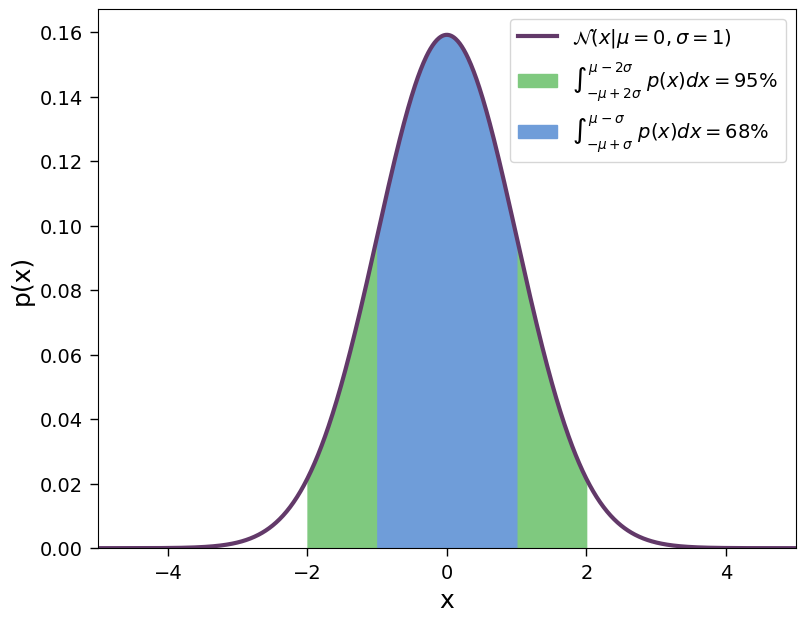

In [24]:
plot_normal(-5, 5, mu=0, sigma=1)

### Estimating the confidence interval of mean of a normal distribution

[a,b] = [-0.005, 0.058], |[a,b]| = 0.063


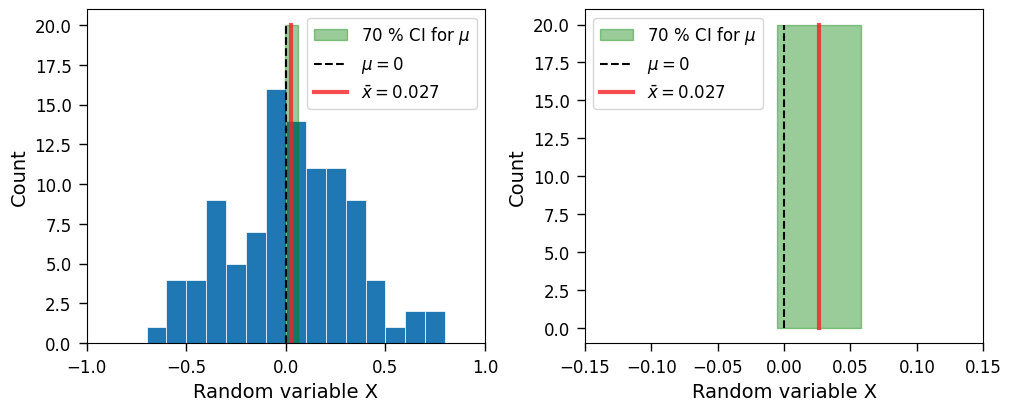

In [34]:
def generate_normal_data(mu, sigma, N):
    rng = np.random.default_rng()
    x = rng.normal(mu, sigma, N)
    return x

# Set number of data points
n = 100

# Generate data from normal distribution with mean=0 and standard deviation=0.3
data_x = generate_normal_data(0, 0.3, n)

# Calculate sample average and sample standard deviation
average = np.average(data_x)
sample_std = np.std(data_x)

# Choose confidence interval level and calculate interval
ci_level = 0.7
alpha = 1 - ci_level
t_val = stats.t(df=n-2).ppf(1-(alpha)/2)
ci_lower = average - t_val*sample_std/np.sqrt(n)
ci_upper = average + t_val*sample_std/np.sqrt(n)
print(f"[a,b] = [{ci_lower:.3f}, {ci_upper:.3f}], |[a,b]| = {np.abs(ci_upper-ci_lower):.3f}")

# Plot results
fig, axs = plt.subplots(ncols=2,figsize=(10,4), layout='constrained')
axs[0].hist(x=data_x, linewidth=0.5, edgecolor="white", bins=20, range=[-1,1])
for ax in axs:
    ax.fill_between([ci_lower, ci_upper], 0, 20, color='green', alpha=0.4, label=fr"{(1-alpha)*100:.0f} % CI for $\mu$")
    ax.plot([0, 0], [0,20], color="black", linestyle="--", label =r"$\mu=0$")
    ax.plot([average, average], [0,20], color="#f42023d6", alpha=0.8, label =rf"$\bar{{x}}={average:.3f}$", linewidth=3)
    ax.set_xlabel("Random variable X", fontsize=14)
    ax.set_ylabel("Count", fontsize=14)
    ax.legend(fontsize=12)
    ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=5, length=6, width=1, labelsize=12)
axs[0].set_xlim(-1,1)
axs[1].set_xlim(-0.15,0.15)
plt.show()

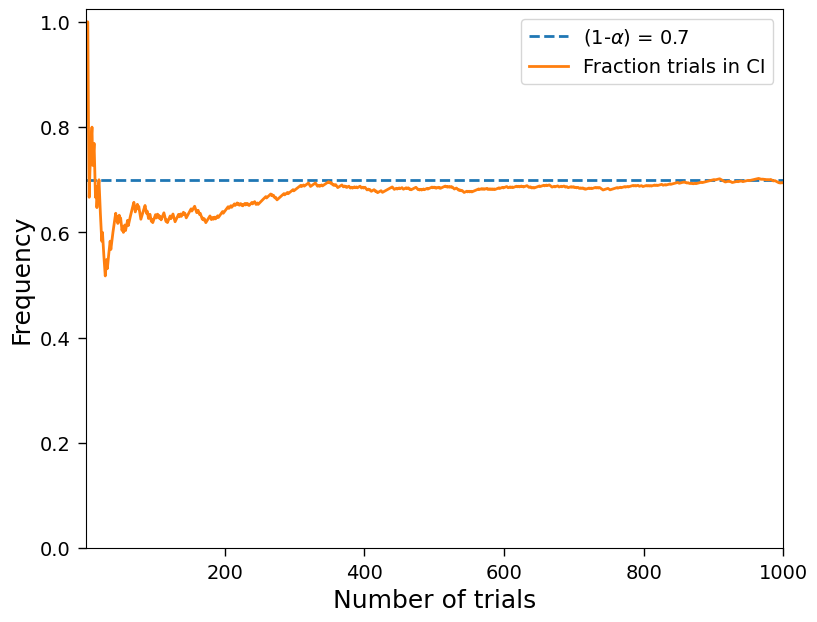

In [36]:
run_normal_experiment(N_experiment=1000, N_data=100, ci_level=0.7)

### Estimating the prediction interval of a normal distribution

[a,b] = [-0.362, 0.261], |[a,b]| = 0.623


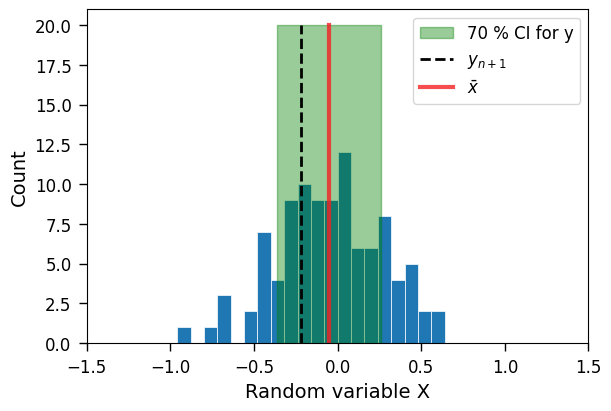

In [37]:
# Set number of data points
n = 100

# Generate data from normal distribution with mean=0 and standard deviation=0.3
data_x = generate_normal_data(0, 0.3, n)

# Calculate average and sample standard deviation
average = np.average(data_x)
sample_std = np.std(data_x)

# Choose confidence interval level and calculate interval
ci_level = 0.7
alpha = 1 - ci_level
ci_lower = average - sample_std
ci_upper = average + sample_std
print(f"[a,b] = [{ci_lower:.3f}, {ci_upper:.3f}], |[a,b]| = {np.abs(ci_upper-ci_lower):.3f}")

# Generate one new value
next_x = generate_normal_data(0, 0.3, 1)

# Plot results
fig, ax = plt.subplots(ncols=1,figsize=(6,4), layout='constrained')
ax.hist(x=data_x, linewidth=0.5, edgecolor="white", bins=30, range=[-1.2,1.2])
ax.fill_between([ci_lower, ci_upper], 0, 20, color='green', alpha=0.4, label=f"{(1-alpha)*100:.0f} % CI for y")
ax.plot([next_x, next_x], [0,20], color="black", linestyle="--", label =r"$y_{n+1}$", linewidth=2)
ax.plot([average, average], [0,20], color="#f42023d6", alpha=0.8, label =r"$\bar{x}$", linewidth=3)
ax.set_xlabel("Random variable X", fontsize=14)
ax.set_ylabel("Count", fontsize=14)
ax.legend(fontsize=12)
ax.set_xlim(-1.5,1.5)
ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=5, length=6, width=1, labelsize=12)
plt.show()

## Regression problems

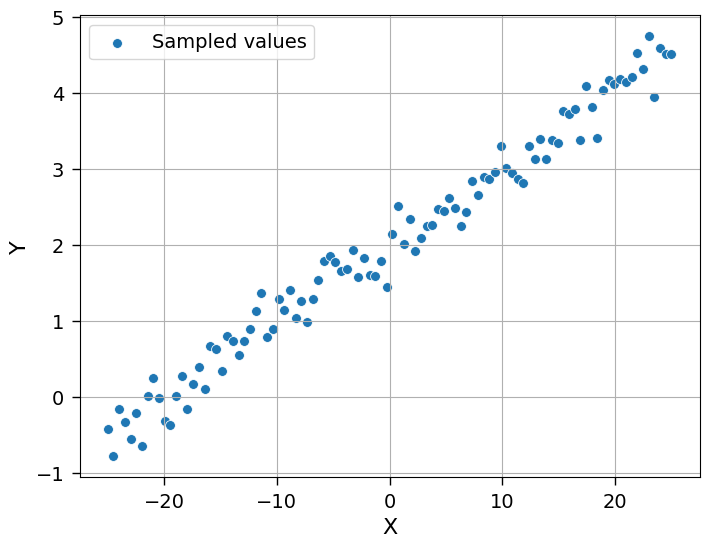

In [38]:
data_x, data_y, y_mu = generate_linear_data(-25, 25, N=100)
data_df = pd.DataFrame({"x":data_x, "y": data_y, "y_mu": y_mu})
plot_data(data_df)

### Estimating confidence interval for mean and y in linear model

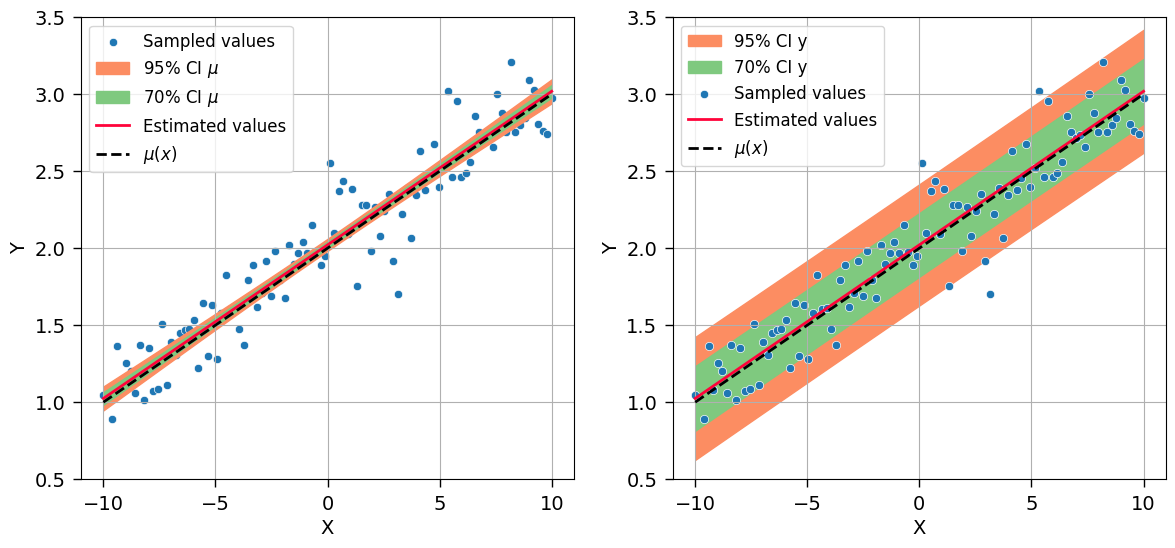

In [39]:
data_x, data_y, y_mu = generate_linear_data(-10, 10, N=100)
data_df = pd.DataFrame({"x":data_x, "y": data_y, "y_mu": y_mu})
data_df, a_est, b_est, sample_var = linear_regression(data_df)
data_df = data_df.sort_values(by="x")
plot_predictions(data_df, ymin=0.5, ymax=3.5)

In [40]:
experiment1_df = repeated_experiment(N=1000, stat_model="LR", N_data=100)
experiment1_df

100%|██████████| 1000/1000 [00:10<00:00, 92.64it/s]


,95CI_y_lower,a,b,var,A_est,B_est,sample_var,var_est,efficiency_95CI_mu,efficiency_95CI_y,efficiency_70CI_y
0,0.0,2,0.1,0.04,2.004732,0.105450,0.046484,0.047433,1.00,0.99,0.69
1,0.0,2,0.1,0.04,1.998923,0.104979,0.037676,0.038445,1.00,0.93,0.76
2,0.0,2,0.1,0.04,2.051405,0.098052,0.042375,0.043240,0.51,0.98,0.69
3,0.0,2,0.1,0.04,2.039440,0.099926,0.032893,0.033564,0.75,0.96,0.75
4,0.0,2,0.1,0.04,2.012404,0.103536,0.048098,0.049079,1.00,0.96,0.69
...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,2,0.1,0.04,2.022364,0.104605,0.034913,0.035625,1.00,0.96,0.70
996,0.0,2,0.1,0.04,1.993611,0.096592,0.044572,0.045481,1.00,0.95,0.72
997,0.0,2,0.1,0.04,2.014987,0.090838,0.036831,0.037583,0.64,0.96,0.76
998,0.0,2,0.1,0.04,2.017100,0.098432,0.025196,0.025710,1.00,0.97,0.67


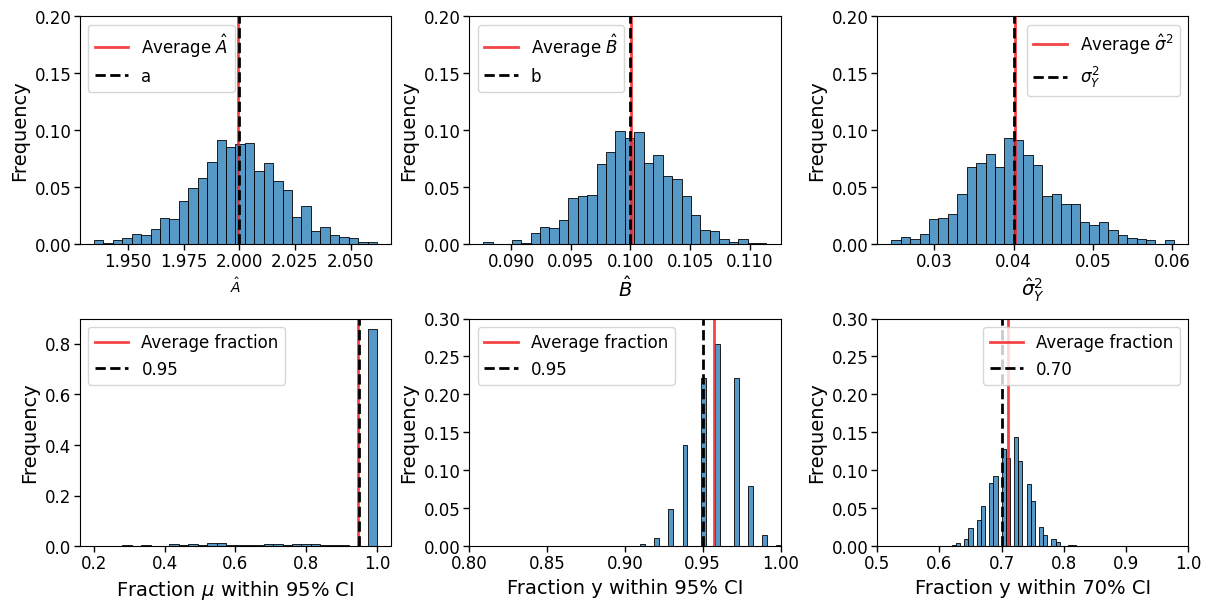

In [41]:
plot_experiment_LR(experiment1_df)

## But what if our data does not fit the linear model?

In [ ]:
data_x, data_y, y_mu = generate_heteroscedastic_data(-10, 10, N=200)
data_df = pd.DataFrame({"x":data_x, "y": data_y, "y_mu": y_mu})
data_df = data_df.sort_values(by="x")
plot_data(data_df)

In [ ]:
data_df, a_est, b_est, sample_var = linear_regression(data_df)
print(a_est, b_est, sample_var)
plot_predictions(data_df, ymin=1, ymax=4.5)

In [ ]:
experiment2_df = repeated_experiment(stat_model="LR", linear=False, const_var=False, N_data=200)
experiment2_df
plot_experiment_LR(experiment2_df)

## Neural network


## Machine learning training
We want the losses to converge, and we have to make sure to not let the validation loss explode

Now we will add a prediction of $\sigma(x)$ to the model to create a prediction interval.

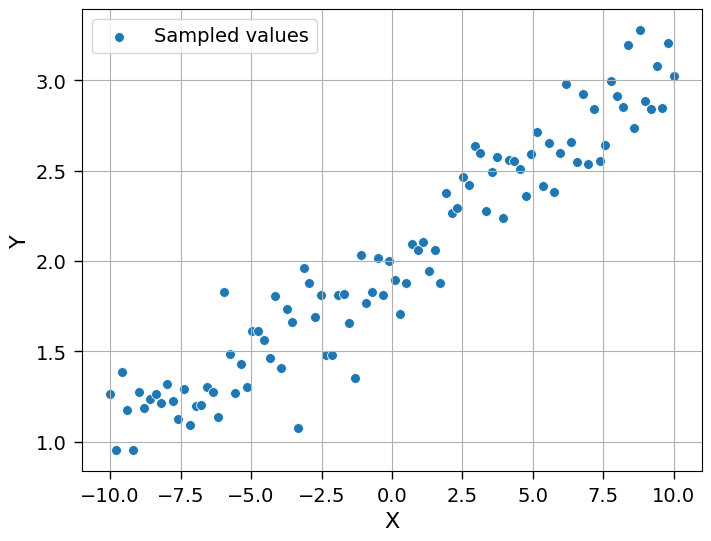

In [42]:
data_x, data_y, y_mu = generate_linear_data(-10, 10, N=100, b=0.1)
data_df = pd.DataFrame({"x":data_x, "y": data_y, "y_mu": y_mu})
data_df = data_df.sort_values(by="x")
plot_data(data_df)

Creating training and validation sets of size (90, 10)
Stopping training at epoch 76


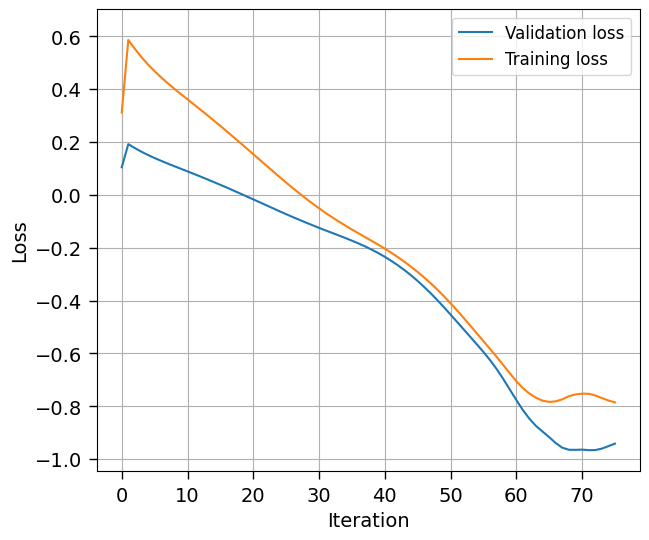

In [46]:
gaussianNLL = True
test_df, training_df = train_nn(data_df, data_df, lr=0.0001, n_hidden=3, n_nodes=300, batchsize=90, patience=5, gaussianNLL=gaussianNLL)
plot_training_results(training_df)

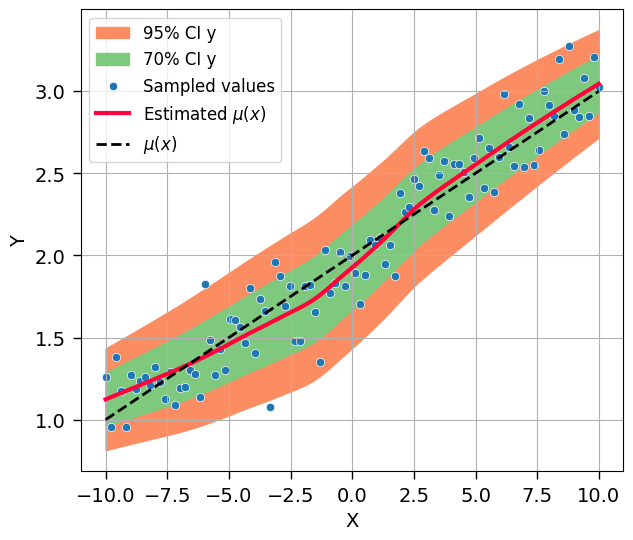

In [47]:
plot_nn_predictions(test_df, gaussianNLL=True)

In [ ]:
experiment3_df = repeated_experiment(stat_model="NN", N=100)
plot_experiment_NN(experiment3_df)

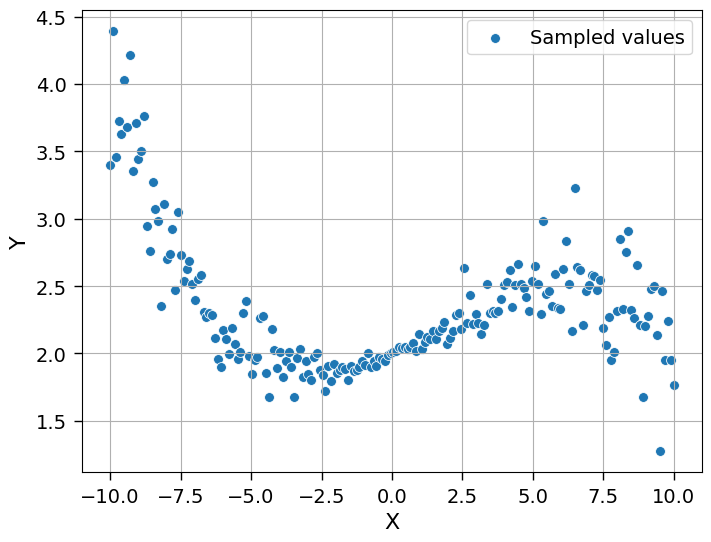

In [48]:
data_x, data_y, y_mu = generate_heteroscedastic_data(-10, 10, N=200)
data_df = pd.DataFrame({"x":data_x, "y": data_y, "y_mu": y_mu})
data_df = data_df.sort_values(by="x")
plot_data(data_df)

Creating training and validation sets of size (180, 20)
Stopping training at epoch 127


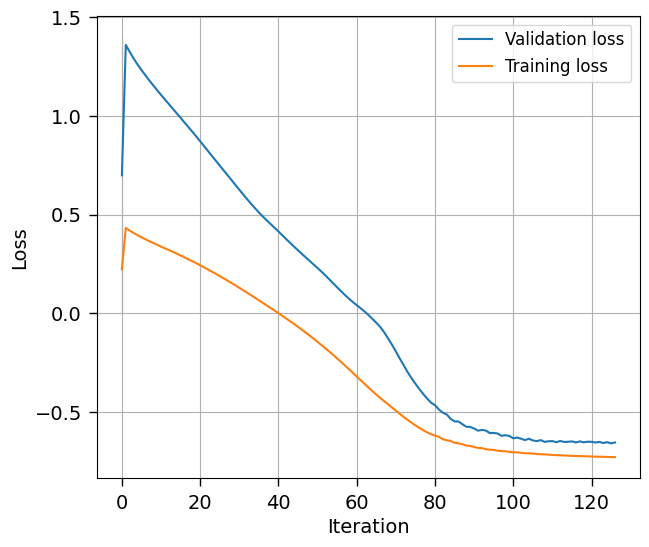

In [49]:
gaussianNLL = True
test_df, training_df = train_nn(data_df, data_df, lr=0.0001, n_hidden=3, n_nodes=300, batchsize=180, patience=20, gaussianNLL=gaussianNLL, epochs=250)
plot_training_results(training_df)

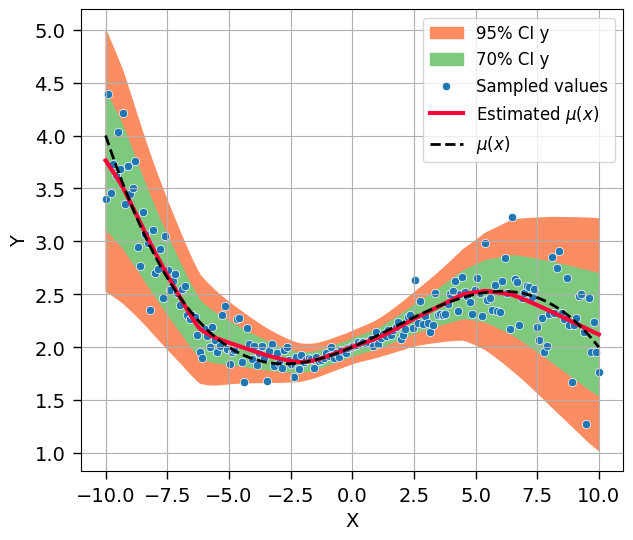

In [50]:
plot_nn_predictions(test_df, gaussianNLL=True)

In [ ]:
experiment4_df = repeated_experiment(stat_model="NN", N=100)
plot_experiment_NN(experiment4_df)